# 베이지안 최적화

* grid search의 단점 : 개별 하이퍼 파라미터 개수가 많으면 수행시간이 오래걸림
* 가우시안process  
  1.대체모델, 획득함수  
  2.하이퍼파라미터를 랜덤으로 사용해서 대체모델(대략적인 성능 예측모델)이 발견된 관측값을 기준으로 근사 성능예측함수를 만든다.  
  3.획득함수는 성능예측함수의 최적값(최고성능,하이퍼파라미터)보다 더 나은 성능을 가질 가능성이 있는 부분의 하이퍼파라미터와 성능을 찾는다.  
  획득함수가 하이퍼파라미터 조합을 찾는다 (아직 성능은 예측치일 뿐)  
  3-2그 조합으로 실제 모델을 학습시켜서 진짜 성능을 확인한다  
  4.다시 대체모델은 하이퍼파라미터를 받아서 성능값으로 기존의 근사 성능예측함수를 업데이트  
  5.반복하면서 성능예측함수를 정밀화함

In [49]:
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.metrics import precision_score, recall_score
from sklearn.metrics import f1_score, roc_auc_score

def get_clf_eval(y_test, pred=None, pred_proba=None):
    confusion = confusion_matrix( y_test, pred)
    accuracy = accuracy_score(y_test , pred)
    precision = precision_score(y_test , pred)
    recall = recall_score(y_test , pred)
    f1 = f1_score(y_test,pred)
    # ROC-AUC 추가 
    roc_auc = roc_auc_score(y_test, pred_proba)
    print('오차 행렬')
    print(confusion)
    # ROC-AUC print 추가
    print('정확도: {0:.4f}, 정밀도: {1:.4f}, 재현율: {2:.4f},\
    F1: {3:.4f}, AUC:{4:.4f}'.format(accuracy, precision, recall, f1, roc_auc))

# HyperOpt(TPE)

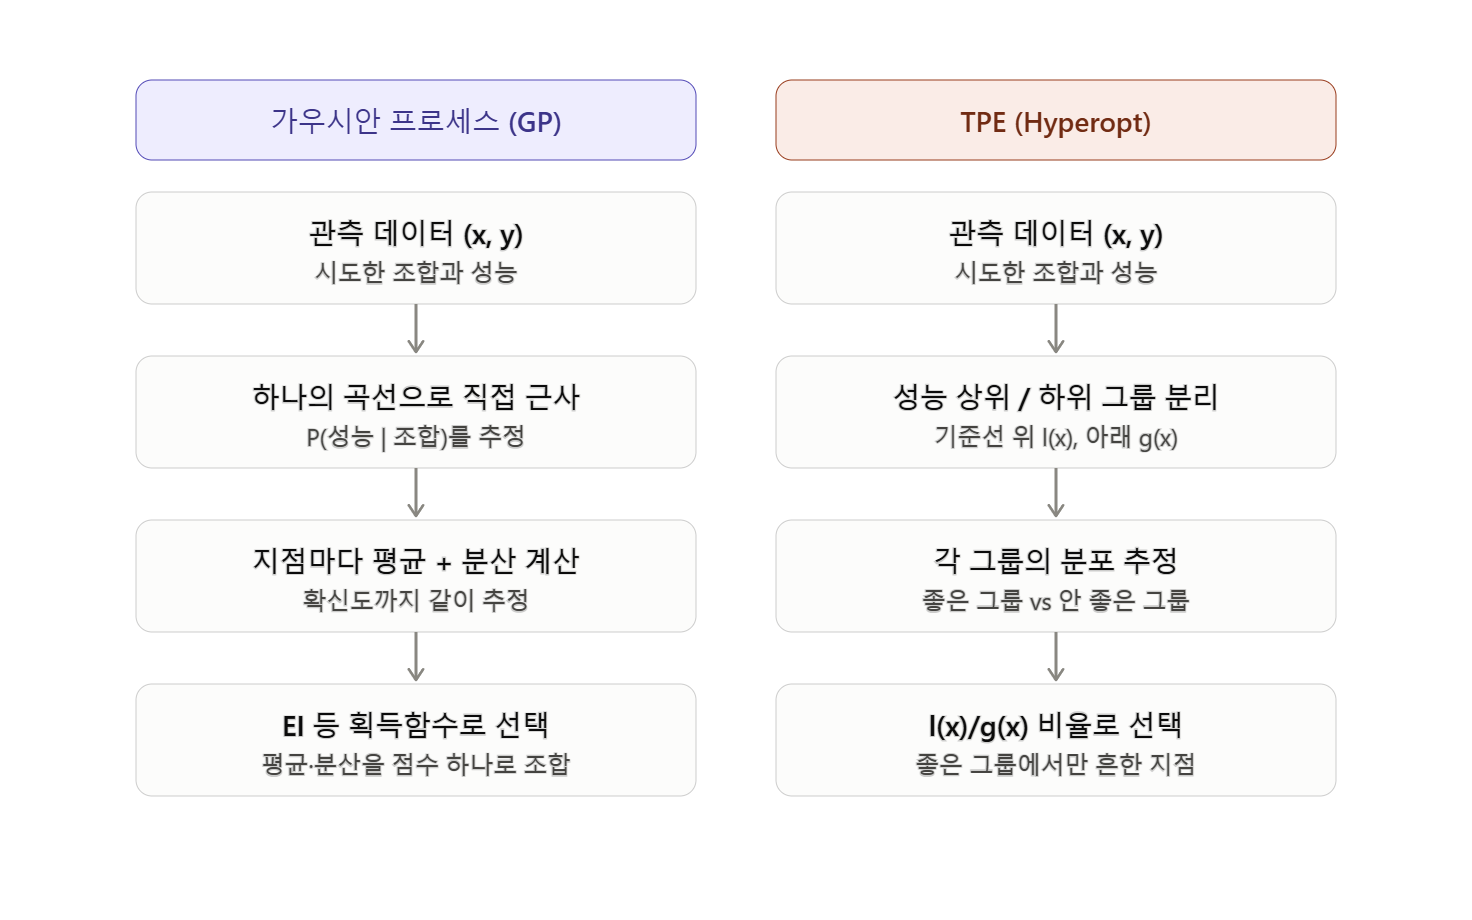

In [10]:
from hyperopt import hp
import numpy as np

#검색공간,입력공간x = -10~10 y= -15~15
search_space={'x':hp.quniform('x',-10,10,1),'y':hp.quniform('y',-15,15,1)}

In [13]:
#목적함수 생성하기, 반드시 변숫값과 검색공간을 가지는 딕셔너리를 인자로 받음
from hyperopt import STATUS_OK

def objective_fuc(search_space):
    x=search_space['x']  # x의 숫자 -10~10중 1개 
    y=search_space['y']  #y의 숫자-15~15중1개
    retval =x**2-20*y

    return retval

In [14]:
from hyperopt import fmin,tpe,Trials

#객체값 생성
trial_val=Trials()

#목적 함수의 최솟값을 반환하는 최적 입력 변숫값을 5번으로 제한
best_01=fmin(fn=objective_fuc,space=search_space,algo=tpe.suggest,max_evals=5,trials=trial_val,rstate=np.random.default_rng(seed=0))

print('best',best_01)

100%|█████████████████████████████████████████████████████████████| 5/5 [00:00<00:00, 596.65trial/s, best loss: -224.0]
best {'x': np.float64(-4.0), 'y': np.float64(12.0)}


In [15]:
from hyperopt import fmin,tpe,Trials

#객체값 생성
trial_val=Trials()

#목적 함수의 최솟값을 반환하는 최적 입력 변숫값을 5번으로 제한
best_01=fmin(fn=objective_fuc,space=search_space,algo=tpe.suggest,max_evals=20,trials=trial_val,rstate=np.random.default_rng(seed=0))

print('best',best_01)

100%|██████████████████████████████████████████████████████████| 20/20 [00:00<00:00, 1053.81trial/s, best loss: -296.0]
best {'x': np.float64(2.0), 'y': np.float64(15.0)}


In [17]:
print(trial_val.results)
print(trial_val.vals)

[{'loss': -64.0, 'status': 'ok'}, {'loss': -184.0, 'status': 'ok'}, {'loss': 56.0, 'status': 'ok'}, {'loss': -224.0, 'status': 'ok'}, {'loss': 61.0, 'status': 'ok'}, {'loss': -296.0, 'status': 'ok'}, {'loss': -40.0, 'status': 'ok'}, {'loss': 281.0, 'status': 'ok'}, {'loss': 64.0, 'status': 'ok'}, {'loss': 100.0, 'status': 'ok'}, {'loss': 60.0, 'status': 'ok'}, {'loss': -39.0, 'status': 'ok'}, {'loss': 1.0, 'status': 'ok'}, {'loss': -164.0, 'status': 'ok'}, {'loss': 21.0, 'status': 'ok'}, {'loss': -56.0, 'status': 'ok'}, {'loss': 284.0, 'status': 'ok'}, {'loss': 176.0, 'status': 'ok'}, {'loss': -171.0, 'status': 'ok'}, {'loss': 0.0, 'status': 'ok'}]
{'x': [np.float64(-6.0), np.float64(-4.0), np.float64(4.0), np.float64(-4.0), np.float64(9.0), np.float64(2.0), np.float64(10.0), np.float64(-9.0), np.float64(-8.0), np.float64(-0.0), np.float64(-0.0), np.float64(1.0), np.float64(9.0), np.float64(6.0), np.float64(9.0), np.float64(2.0), np.float64(-2.0), np.float64(-4.0), np.float64(7.0), np.

In [21]:
import pandas as pd

losses =[loss_dict['loss'] for loss_dict in trial_val.results] # 사전형에서 리스트

result_df=pd.DataFrame({'x':trial_val.vals['x'],'y':trial_val.vals['y'],'losses':losses})


In [23]:
result_df.head()

,x,y,losses
0,-6.0,5.0,-64.0
1,-4.0,10.0,-184.0
2,4.0,-2.0,56.0
3,-4.0,12.0,-224.0
4,9.0,1.0,61.0


# xgboost 하이퍼 파라미터 최적화

In [38]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_breast_cancer
import xgboost as xgb
from xgboost import plot_importance


dataset=load_breast_cancer()

cancer_df=pd.DataFrame(data=dataset.data,columns=dataset.feature_names)
cancer_df['target']=dataset.target
X_features=cancer_df.iloc[:,:-1]
y_label=cancer_df.iloc[:,-1]

X_train,X_test,y_train,y_test=train_test_split(X_features,y_label,test_size=0.2,random_state=42)

x_tr,x_val,y_tr,y_val=train_test_split(X_train,y_train,test_size=0.1,random_state=42)

In [39]:
from hyperopt import hp

xgb_search_space={'max_depth':hp.quniform('max_depth',5,20,1),'min_child_weight':hp.quniform('min_child_weight',1,2,1),
                 'learning_rate':hp.uniform('learning_rate',0.01,0.2),'colsample_bytree':hp.uniform('colsample_bytree',0.5,1)}
# colsample_bytree 분기시 전체 변수중 몇%만쓸까? => 특정 변수에 의존한 분기 방지 ,tree의 다양성 보존

In [42]:
# 목적함수 만들기
# 반드시 정수형전달, 성능이 높을수록 좋다면 -붙이기

from sklearn.model_selection import cross_val_score
from xgboost import XGBClassifier
from hyperopt import STATUS_OK

def objective_func(search_space):
    xgb_clf=XGBClassifier(n_estimators=100,max_depth=int(search_space['max_depth']),min_child_weight=int(search_space['min_child_weight']),
                          learning_rate=search_space['learning_rate'],
                          colsample_bytree=search_space['colsample_bytree']
                         )
    accuracy=cross_val_score(xgb_clf,X_train,y_train,scoring='accuracy',cv=3)

    return {'loss':-1*np.mean(accuracy),'status':STATUS_OK}
                          

In [43]:
# 최적의 하이퍼파라미터 도출하기

from hyperopt import fmin,tpe, Trials

trial_val=Trials()
best=fmin(fn=objective_func,
          space=xgb_search_space,
          algo=tpe.suggest,
          max_evals=50,
          trials=trial_val
          ,rstate=np.random.default_rng(seed=19))

100%|███████████████████████████████████████████████| 50/50 [00:12<00:00,  4.13trial/s, best loss: -0.9714186127570582]


In [44]:
print('best',best)

best {'colsample_bytree': np.float64(0.8523879859517168), 'learning_rate': np.float64(0.08067116159101718), 'max_depth': np.float64(10.0), 'min_child_weight': np.float64(2.0)}


In [50]:
# 하이퍼파라미터단계에서 cv를 했기 때문에,최종모델 학습단계에서는 cv를할필요가없다
xgb_rapper=XGBClassifier(n_estimators=100,max_depth=int(best['max_depth']),min_child_weight=int(best['min_child_weight']),
                          learning_rate=best['learning_rate'],
                          colsample_bytree=best['colsample_bytree']
                         ,early_stopping_rounds=50,eval_metrics='logloss') # 앞에서 accuracy는 하이퍼파라미터를 고를때 기준 , 여기서를 조기종료,언제학습을멈출까라 metric이 달라도됨

evals=[(x_tr,y_tr),(x_val,y_val)]

xgb_rapper.fit(x_tr,y_tr,eval_set=evals,verbose=True) # 데이터손해를 감수하더라도 X_trian을 전체를 쓰지않고 tr과 val을써서 얼리스탑을하는것

pred=xgb_rapper.predict(X_test)
pred_proba=xgb_rapper.predict_proba(X_test)[:,1]

get_clf_eval(y_test,pred,pred_proba)


[0]	validation_0-logloss:0.59663	validation_1-logloss:0.58543
[1]	validation_0-logloss:0.54225	validation_1-logloss:0.53252
[2]	validation_0-logloss:0.49431	validation_1-logloss:0.49013
[3]	validation_0-logloss:0.45215	validation_1-logloss:0.45015
[4]	validation_0-logloss:0.41531	validation_1-logloss:0.41676
[5]	validation_0-logloss:0.38355	validation_1-logloss:0.38674
[6]	validation_0-logloss:0.35478	validation_1-logloss:0.36407
[7]	validation_0-logloss:0.33005	validation_1-logloss:0.33997
[8]	validation_0-logloss:0.30654	validation_1-logloss:0.31804
[9]	validation_0-logloss:0.28592	validation_1-logloss:0.30020
[10]	validation_0-logloss:0.26685	validation_1-logloss:0.28762
[11]	validation_0-logloss:0.24937	validation_1-logloss:0.27125
[12]	validation_0-logloss:0.23422	validation_1-logloss:0.25754
[13]	validation_0-logloss:0.22041	validation_1-logloss:0.24260
[14]	validation_0-logloss:0.20781	validation_1-logloss:0.23171
[15]	validation_0-logloss:0.19539	validation_1-logloss:0.22325
[1

C:\Users\rhals\anaconda3\Lib\site-packages\xgboost\callback.py:386: UserWarning: [15:03:34] WARNING: C:\b\abs_d97hy_84m6\croot\xgboost-split_1749630932152\work\src\learner.cc:738: 
Parameters: { "eval_metrics" } are not used.

  self.starting_round = model.num_boosted_rounds()


[93]	validation_0-logloss:0.02345	validation_1-logloss:0.07285
[94]	validation_0-logloss:0.02335	validation_1-logloss:0.07272
[95]	validation_0-logloss:0.02314	validation_1-logloss:0.07261
[96]	validation_0-logloss:0.02293	validation_1-logloss:0.07108
[97]	validation_0-logloss:0.02276	validation_1-logloss:0.07109
[98]	validation_0-logloss:0.02253	validation_1-logloss:0.07072
[99]	validation_0-logloss:0.02234	validation_1-logloss:0.07063
오차 행렬
[[40  3]
 [ 2 69]]
정확도: 0.9561, 정밀도: 0.9583, 재현율: 0.9718,    F1: 0.9650, AUC:0.9905
